In [1]:
import pandas as pd

from os import listdir, path
from os.path import isfile, join

from matplotlib import pyplot as plt
from scipy.interpolate import interp1d

from tabulate import tabulate
import numpy as np


from mpl_toolkits.axes_grid1.inset_locator import inset_axes 
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

import ast
import seaborn as sns

In [2]:
cn = [('','dataset'), ('','client'),
     ('CFL (Ours)','Precision'),('CFL (Ours)','Recal'),('CFL (Ours)','F1'),
     ('LL','Precision'),('LL','Recal'),('LL','F1'),
     # ('CFL-L','Precision'),('CFL-L','Recal'),('CFL-L','F1'),
     ('SubTab','Precision'),('SubTab','Recal'),('SubTab','F1'),
     ('SubTab-FL','Precision'),('SubTab-FL','Recal'),('SubTab-FL','F1'),
     ('Base','Precision'),('Base','Recal'),('Base','F1')
     ]
cnS = [('','dataset'), ('','client'),
       ('Base','Precision'),('Base','Recal'),('Base','F1'),
       ('CFL (Ours)','Precision'),('CFL (Ours)','Recal'),('CFL (Ours)','F1'),
       # ('CFL-L','Precision'),('CFL-L','Recal'),('CFL-L','F1'),
       ('LL','Precision'),('LL','Recal'),('LL','F1'),
       ('SubTab','Precision'),('SubTab','Recal'),('SubTab','F1'),
       ('SubTab-FL','Precision'),('SubTab-FL','Recal'),('SubTab-FL','F1'),
     ]
cnR = [('dataset'), ('client'),
       ('Base-Precision'),('Base-Recal'),('Base-F1'),
       ('CFL-Precision (Ours)'),('CFL-Recal (Ours)'),('CFL-F1 (Ours)'),
       # ('CFL-L-Precision'),('CFL-L-Recal'),('CFL-L-F1'),
       ('LL-Precision'),('LL-Recal'),('LL-F1'),
       ('SubTab-Precision'),('SubTab-Recal'),('SubTab-F1'),
       ('SubTab-FL-Precision'),('SubTab-FL-Recal'),('SubTab-FL-F1'),
     ]
cnnp = [('','dataset'),
     ('Pearson','Precision'),('Pearson','Recal'),('Pearson','F1'),
     ('Not Pearson','Precision'),('Not Pearson','Recal'),('Not Pearson','F1')
     ]

In [3]:
plt.rcParams.update({'font.size': 16})
plt.rc('legend', fontsize=14)    # legend fontsize
plt.rc('legend', title_fontsize=16)    # legend fontsize

In [4]:
# dataset_list = ['covtype']
dataset_list = ['adult','aloi', 'blog','covtype','helena','higgs-small' \
                ,'income','jannis','microsoft','yahoo','year']
# dataset_list += ['blog','covtype', 'income', 'sensorless','tuandromd']

In [5]:
allFiles=[]
for dataset in dataset_list :
    mypath = "results/"+ dataset +"/"
    onlyfiles = [mypath + f for f in listdir(mypath) if isfile(join(mypath, f))]
    onlyfiles = [f for f in onlyfiles if f[-3:] == "csv"]
    allFiles.extend(onlyfiles)
# allFiles


In [6]:
for i, item in enumerate(allFiles):
    # print(item)
    dt = pd.read_csv(item)
    item = item.replace('higgs-small','higgs_small')
    dt["client"] = int(item.split("-")[1])
    dt["epoch"] = int(item.split("-")[2][:-1])
    dt["cluster"] = int(item.split("-")[3][:-2])
    dt["mc"] = float(item.split("-")[4][:-2])
    dt["attack"] = str(item.split("-")[5][:-3])
    dt["defense"] = str(item.split("-")[6][:-3])
    dt["rl"] = int(item.split("-")[7][:-2])
    dt["dataset"] = str(item.split("-")[8])
    dt["cl"] = str(item.split("-")[9])
    dt["classical"] = str(item.split("-")[10])
    
    if i ==0 : db = dt
    else : db = pd.concat([db,dt])
# db = pd.merge(db[db.type == 'original'], db[db.type == 'contrastive'], on=["client","model"])
db.model.unique()

array(['LogReg_10'], dtype=object)

In [7]:
db.client = db.client.apply(lambda x : x+1)
db.test_acc = db.test_acc.apply(lambda x: ast.literal_eval(x)[-2])
db.train_acc = db.train_acc.apply(lambda x: ast.literal_eval(x)[-2])
db.val_acc = db.val_acc.apply(lambda x: ast.literal_eval(x)[-2])

In [8]:
db.columns

Index(['model', 'train_acc', 'test_acc', 'val_acc', 'client', 'epoch',
       'cluster', 'mc', 'attack', 'defense', 'rl', 'dataset', 'cl',
       'classical'],
      dtype='object')

In [9]:
db.head()

,model,train_acc,test_acc,val_acc,client,epoch,cluster,mc,attack,defense,rl,dataset,cl,classical
0,LogReg_10,0.589798,0.672116,0.602353,2,50,6,0.75,model_replacement,momentum,1,adult,ClRetrain,classicalRetrain
0,LogReg_10,0.557405,0.852515,0.825073,5,50,6,0.25,model_replacement,foolsgold,1,adult,ClRetrain,classicalRetrain
0,LogReg_10,0.627332,0.655466,0.567920,1,50,6,0.75,targeted,multi_krum,1,adult,ClNoRetrain,classicalRetrain
0,LogReg_10,0.463705,0.367354,0.223598,2,50,6,0.50,targeted,robust,1,adult,ClRetrain,classicalNoRetrain
0,LogReg_10,0.706543,0.751181,0.670116,6,50,6,0.50,model_replacement,momentum,1,adult,ClNoRetrain,classicalRetrain


In [10]:
db['attack'].unique()

array(['model_replacement', 'targeted', 'scale', 'gradient_ascent',
       'direction'], dtype=object)

In [12]:
db.groupby(['mc', 'attack', 'defense', 'rl', 'dataset', 'cl',
       'classical'])['test_acc'].mean().to_csv('data.csv')

In [27]:
data = db.groupby(['mc', 'attack', 'defense', 'rl', 'dataset', 'cl',
       'classical'])['test_acc'].mean().reset_index()

In [29]:
data['methods'] = data.cl + '-' + data.classical

In [81]:

df_plot = data.groupby(['attack','defense','methods'])['test_acc'].mean().reset_index().pivot(
    index=['attack','defense'],
    columns='methods',
    values='test_acc'
)
# df_plot = df_plot[['ClNoRetrain-classicalNoRetrain'
#          , 'ClRetrain-classicalRetrain']]
df_plot = df_plot[['ClNoRetrain-classicalNoRetrain',
                   'ClRetrain-classicalNoRetrain']]

# df_plot.columns = ['CL without retrain', 'CL with retrain']

Index(['ClNoRetrain-classicalNoRetrain', 'ClNoRetrain-classicalRetrain',
       'ClRetrain-classicalNoRetrain', 'ClRetrain-classicalRetrain'],
      dtype='object', name='methods')

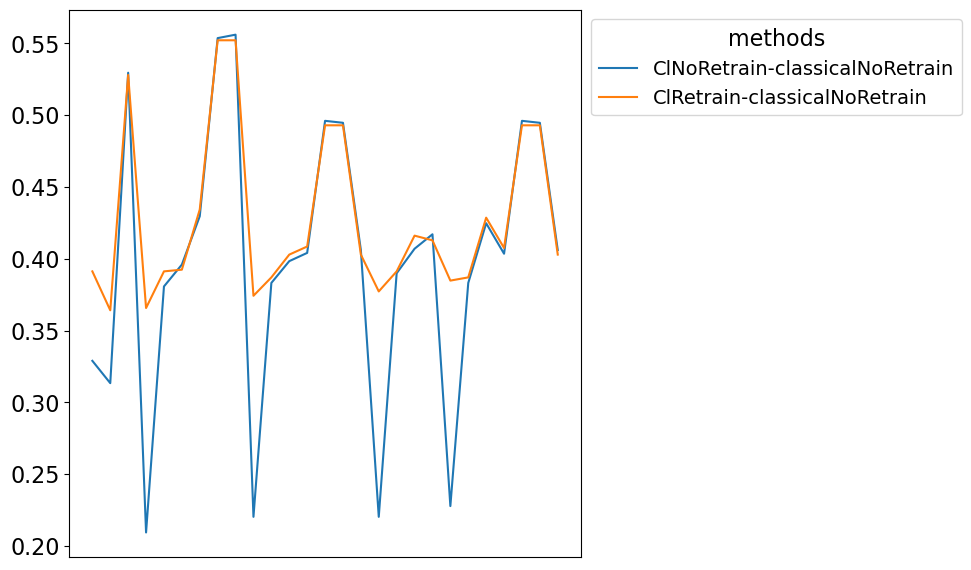

In [82]:
fig, ax = plt.subplots(figsize=(10, 6))


for col in df_plot.columns:
    ax.plot(range(len(df_plot)), df_plot[col], label=col)

ax.set_xticks([])
ax.set_xticklabels([])

ax.legend(
    loc='upper left',
    bbox_to_anchor=(1, 1),
    title='methods'
)

plt.tight_layout()
plt.show()


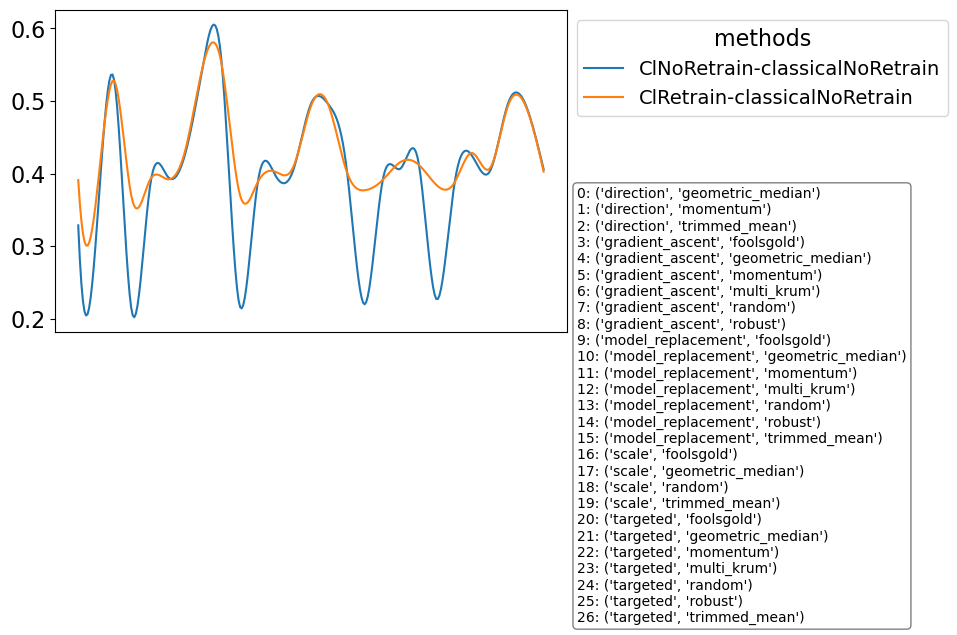

In [83]:
from scipy.interpolate import make_interp_spline
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

# df_plot = data.groupby(['attack','defense','methods'])['test_acc'].mean().reset_index().pivot(
#     index=['attack','defense'],
#     columns='methods',
#     values='test_acc'
# )

x = np.arange(len(df_plot))
x_smooth = np.linspace(x.min(), x.max(), 300)

for col in df_plot.columns:
    y = df_plot[col].values
    spline = make_interp_spline(x, y, k=3)
    y_smooth = spline(x_smooth)
    ax.plot(x_smooth, y_smooth, label=col)

ax.set_xticks([])
ax.set_xticklabels([])

# Main legend
ax.legend(
    loc='upper left',
    bbox_to_anchor=(1, 1),
    title='methods'
)

# X labels list as text below legend
x_labels = [str(i) for i in df_plot.index]
x_label_text = '\n'.join([f'{i}: {label}' for i, label in enumerate(x_labels)])

ax.text(
    1.02, 0.45,           # position (in axes coordinates)
    x_label_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.5)
)

plt.tight_layout()
plt.show()


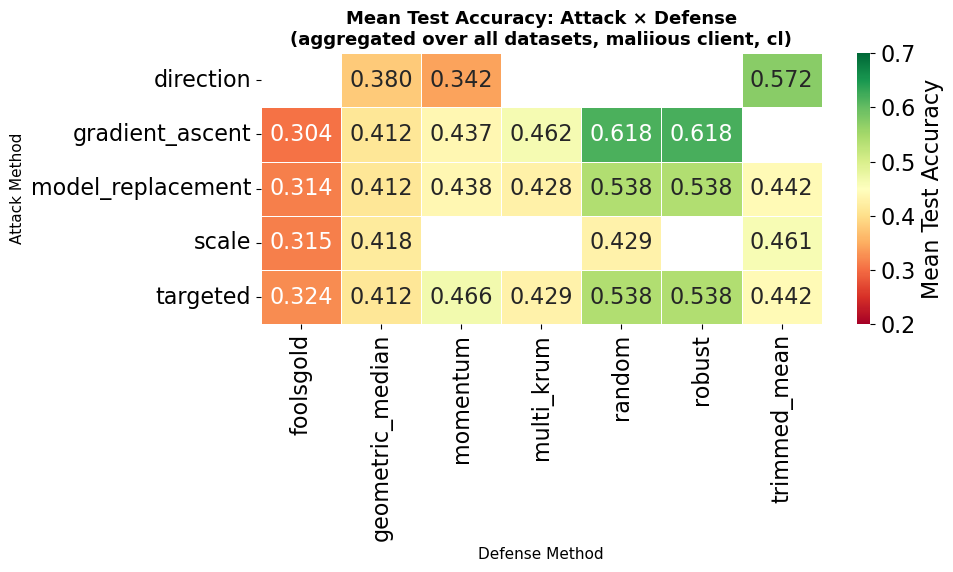

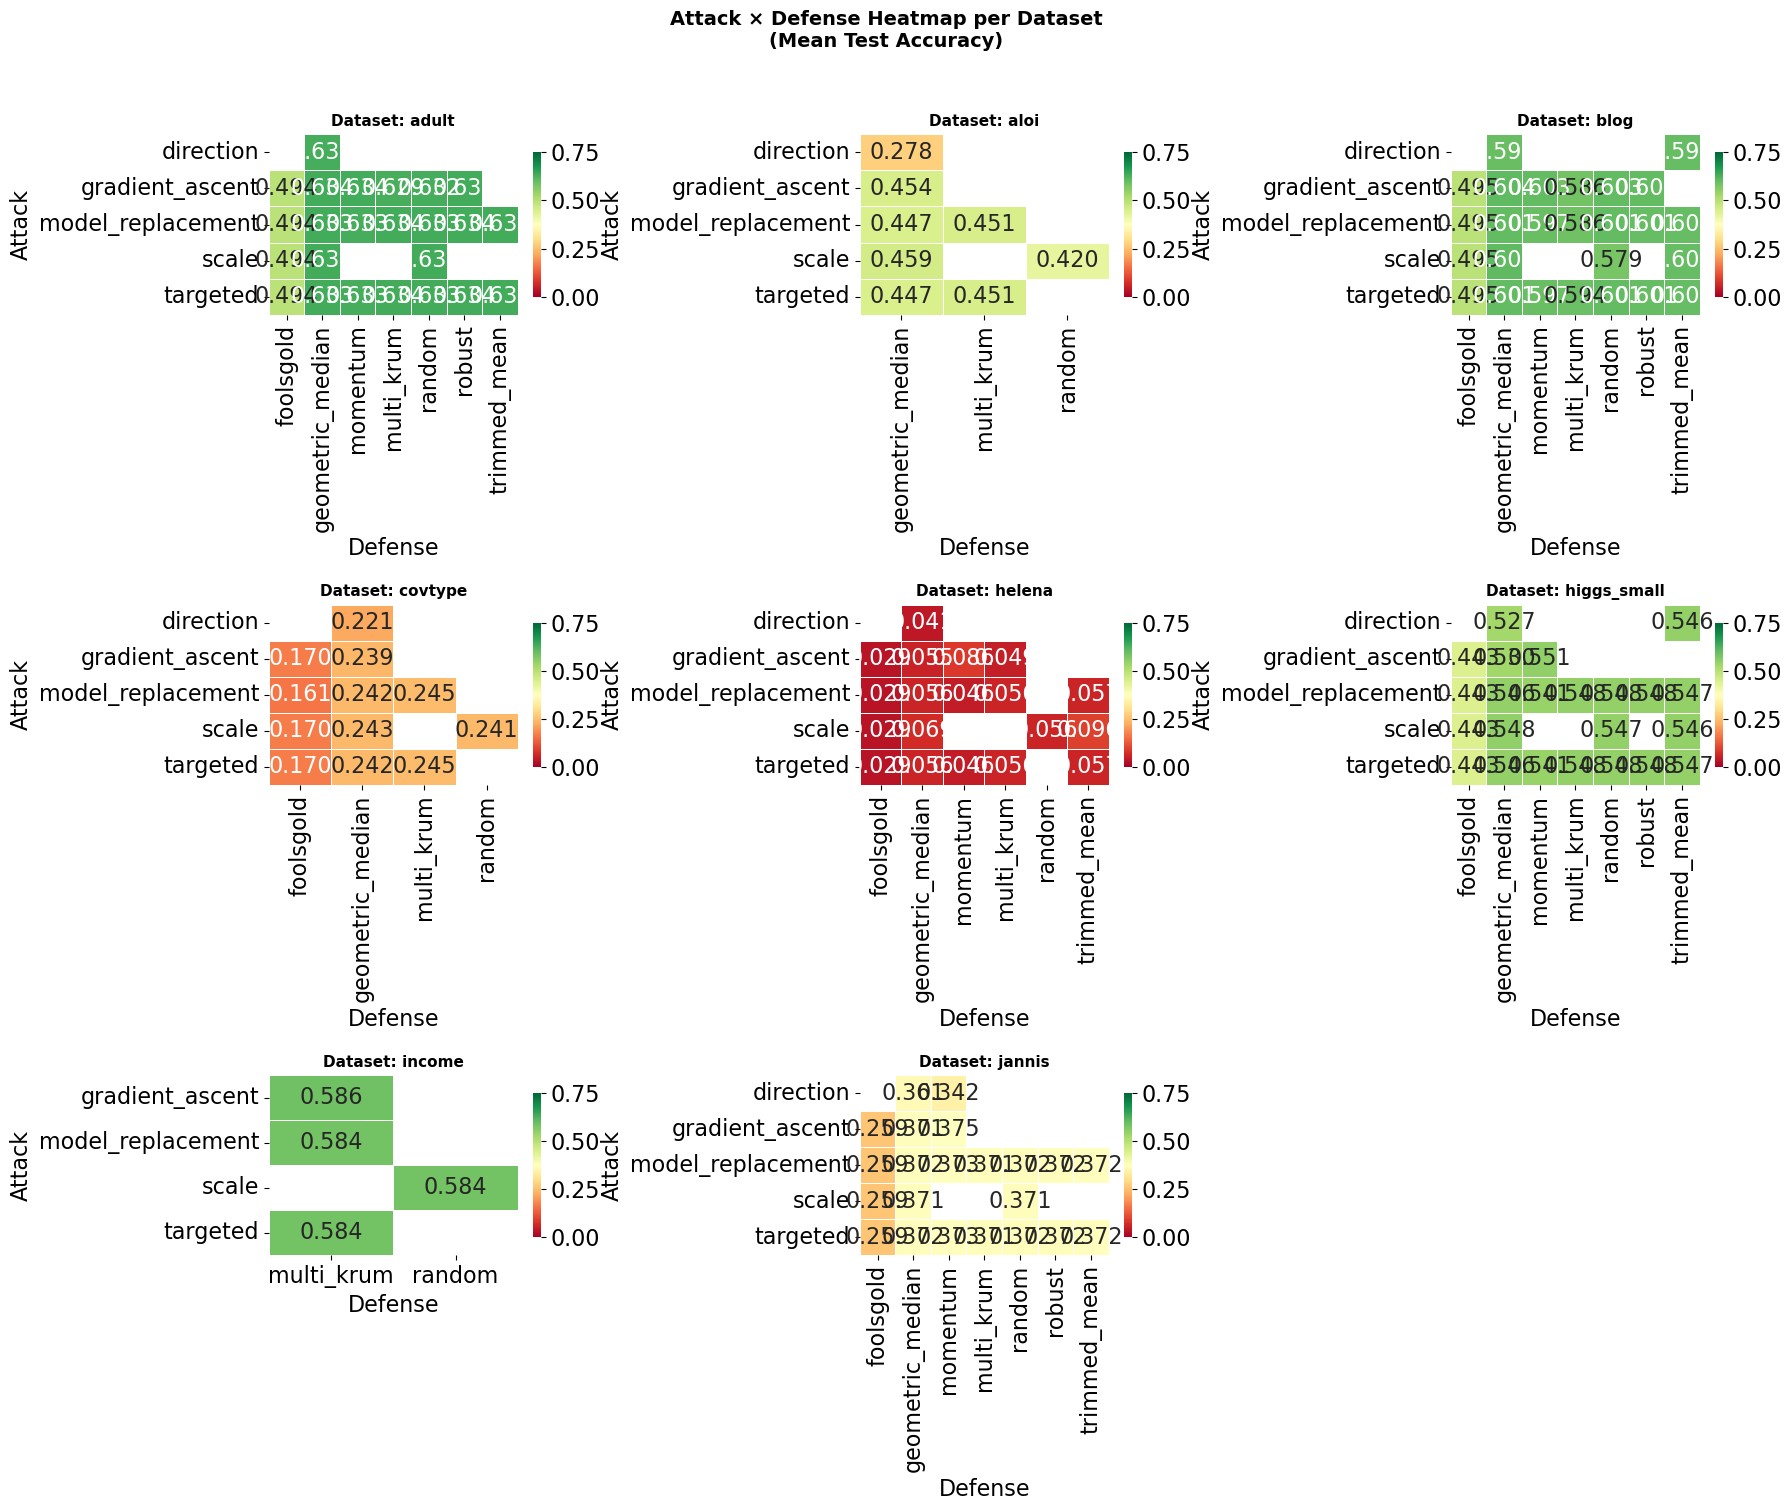

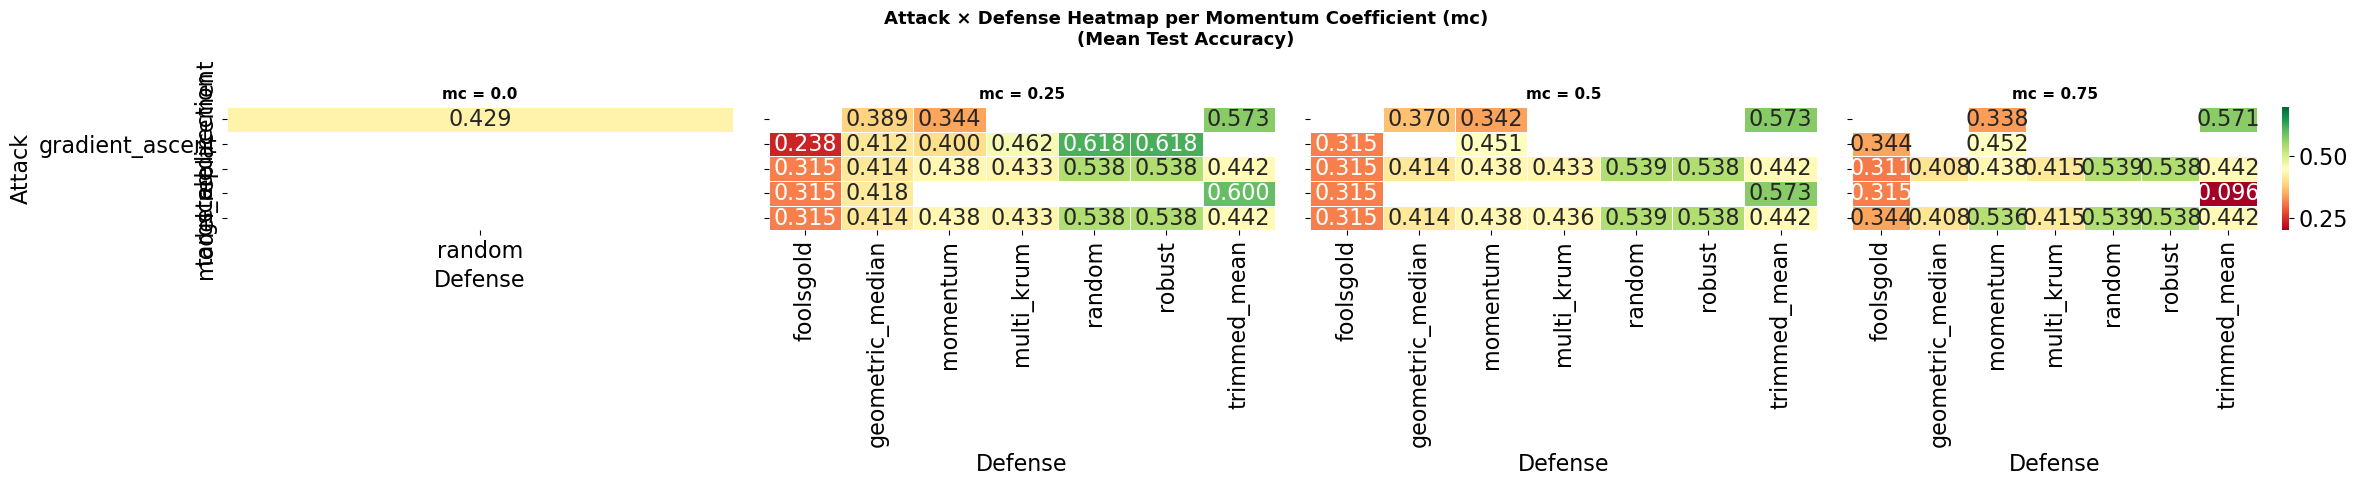

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load your data ──────────────────────────────────────────────────────────
# Replace with your actual file path
df = pd.read_csv("data.csv")  # columns: mc, attack, defense, dataset, cl, classical, test_acc

# ── 1. MAIN HEATMAP: Attack × Defense (mean test_acc across all) ────────────
pivot = df.groupby(["attack", "defense"])["test_acc"].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    pivot,
    annot=True, fmt=".3f",
    cmap="RdYlGn",
    linewidths=0.5,
    linecolor="white",
    vmin=0.2, vmax=0.7,
    ax=ax,
    cbar_kws={"label": "Mean Test Accuracy"}
)
ax.set_title("Mean Test Accuracy: Attack × Defense\n(aggregated over all datasets, maliious client, cl)", fontsize=13, fontweight="bold")
ax.set_xlabel("Defense Method", fontsize=11)
ax.set_ylabel("Attack Method", fontsize=11)
plt.tight_layout()
plt.savefig("heatmap_attack_defense.png", dpi=150)
plt.show()


# ── 2. FACETED HEATMAP: One per Dataset ─────────────────────────────────────
datasets = df["dataset"].unique()
n = len(datasets)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 5))
axes = axes.flatten()

for i, ds in enumerate(sorted(datasets)):
    sub = df[df["dataset"] == ds]
    pivot_ds = sub.groupby(["attack", "defense"])["test_acc"].mean().unstack()
    sns.heatmap(
        pivot_ds,
        annot=True, fmt=".3f",
        cmap="RdYlGn",
        linewidths=0.4,
        linecolor="white",
        vmin=0.0, vmax=0.75,
        ax=axes[i],
        cbar=True,
        cbar_kws={"shrink": 0.8}
    )
    axes[i].set_title(f"Dataset: {ds}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Defense")
    axes[i].set_ylabel("Attack")

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Attack × Defense Heatmap per Dataset\n(Mean Test Accuracy)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("heatmap_per_dataset.png", dpi=150, bbox_inches="tight")
plt.show()


# ── 3. HEATMAP: Attack × Defense per mc value ───────────────────────────────
mc_vals = sorted(df["mc"].unique())
ncols = len(mc_vals)

fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 5), sharey=True)

for i, mc in enumerate(mc_vals):
    sub = df[df["mc"] == mc]
    pivot_mc = sub.groupby(["attack", "defense"])["test_acc"].mean().unstack()
    sns.heatmap(
        pivot_mc,
        annot=True, fmt=".3f",
        cmap="RdYlGn",
        linewidths=0.4,
        linecolor="white",
        vmin=0.2, vmax=0.7,
        ax=axes[i],
        cbar=(i == ncols - 1),
    )
    axes[i].set_title(f"mc = {mc}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Defense")
    if i == 0:
        axes[i].set_ylabel("Attack")
    else:
        axes[i].set_ylabel("")

fig.suptitle("Attack × Defense Heatmap per Momentum Coefficient (mc)\n(Mean Test Accuracy)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("heatmap_per_mc.png", dpi=150)
plt.show()


## Load Base Model

In [95]:
base = pd.read_csv('base.csv')
base.test_acc = base.test_acc.apply(lambda x: ast.literal_eval(x))
base

,dataset,test_acc
0,covtype,"(0.5529311549081724, 0.6008546651291218, 0.560..."
1,sensorless,"(0.16562053992993628, 0.16324437825036014, 0.1..."
2,tuandromd,"(0.9431724763705104, 0.94176, 0.9386746703123356)"
3,syn,"(0.8603006598764303, 0.8605496707701117, 0.859..."
4,blog,"(0.7926394892970967, 0.7957085991602596, 0.791..."
5,income,"(0.820244391751737, 0.8280761579994317, 0.8105..."


In [96]:
db[['model','type']].drop_duplicates()

,model,type
0,original Val,FL
0,contrastive Val,FL


## Load subtab results

In [97]:
ds = pd.read_csv('sbt.csv') #read SubTab
ds['model'] = 'SubTab'
db = pd.concat([db,ds])
ds = pd.read_csv('sbtFL.csv') #read SubTabFL
ds['model'] = 'SubTab FL'
db = pd.concat([db,ds])
db[['model','type']].drop_duplicates()

,model,type
0,original Val,FL
0,contrastive Val,FL
0,SubTab,NaN
0,SubTab FL,SubTab


In [98]:
db.model.unique()
# db.head()

array(['original Val', 'contrastive Val', 'SubTab', 'SubTab FL'],
      dtype=object)

In [99]:
# db.test_acc = db.test_acc.apply(lambda x: ast.literal_eval(x)[-2])
# db.train_acc = db.train_acc.apply(lambda x: ast.literal_eval(x)[-2])

In [100]:
db.model = db.model.apply(lambda x : 'CFL' if x == 'contrastive Val' else x)
db.model = db.model.apply(lambda x : 'LL' if x == 'original Val' else x)

In [101]:
alp = ['0','A','B','C','D','E','F','G','H','I','J','K','L','M','N','O',
      'P','Q']
# db.client = db.client.apply(lambda x : alp[x])

In [102]:
# db[(db.dataset=='syn')&(db.model == 'LL')]
# db.type = db.apply(lambda x : 'local' if (x.dataset=='syn' and x.model == 'LL') else x.type , axis=1)

In [103]:
# db[(db.model=='Base')&(db.dataset=='income')]
# db.type.unique()
db.loc[db.model == 'SubTab FL', 'type'] = 'FL'
db.loc[db.model == 'SubTab', 'type'] = 'FL'
db.type.unique()

array(['FL'], dtype=object)

CFL + LL = local logistic regression each silo
CFL + FL = CFL
SBT = subtab
SBTFL = SubTab FL

## Transform test values as literal list

In [104]:
db.test_acc = db.test_acc.apply(lambda x: ast.literal_eval(x))
# db.test_acc.apply(lambda x: x[0])

## Normal Client

In [105]:
dx = db[(db.client_drop==0)&(db.class_imbalance==0)].copy()
dx.test_acc = dx.test_acc.apply(lambda x: x[-2]).astype('float')
dx = dx[['model','test_acc', 'client', 'type', 'dataset']]\
.pivot(index=['dataset','model','client'],
       values=['test_acc'],
       columns=['type'])\
.reset_index()

dx.columns = ['dataset','model','client','fl']
dx.set_index(['client','dataset'], inplace=True)
dx = dx[dx.model=='CFL'][['fl']].join(
    dx[dx.model=='LL'][['fl']], rsuffix='_LL').join(
    dx[dx.model=='SubTab'][['fl']], rsuffix='_sbt').join(
    dx[dx.model=='SubTab FL'][['fl']], rsuffix='_sbtfl').reset_index()
dx = dx.set_index('dataset').join(base.set_index('dataset'), how='left', rsuffix='base').reset_index()
dx.columns = ['dataset', 'client', 'CFL', 'LR', 'SubTab', 'SubTabFL','Base']
dx.Base = dx.Base.apply(lambda x: x[-2])
dx['dSubTab'] = dx.Base -  dx.SubTab
dx['dSubTabFL'] = dx.Base - dx.SubTabFL
dx['dLL'] = dx.Base - dx.LR
dx['dCFL'] = dx.Base -  dx.CFL
# dx['dCFLLocal'] = dx.Base -  dx.CFLLocal
dx = dx[['client', 'dataset', 'dCFL','dLL','dSubTab', 'dSubTabFL']]
dx.columns = ['client', 'dataset', 'CFL', 'LR','SubTab', 'SubTab FL']
# dx = dx[['client', 'dataset', 'CFL', 'C','LL','SubTab', 'SubTab FL']]
print((dx.groupby('dataset')[['SubTab', 'SubTab FL','LR', 'CFL']].mean())\
.style.to_latex())
dx0=dx.copy()
# dx

\begin{tabular}{lrrrr}
 & SubTab & SubTab FL & LR & CFL \\
dataset &  &  &  &  \\
blog & 0.038829 & 0.071925 & 0.084036 & 0.034348 \\
covtype & 0.243861 & 0.254779 & 0.277010 & 0.214163 \\
income & 0.102250 & 0.166317 & 0.183834 & 0.119485 \\
sensorless & 0.083711 & 0.096671 & 0.148330 & 0.079364 \\
syn & 0.457292 & 0.492561 & 0.084546 & 0.084977 \\
tuandromd & 0.237826 & 0.238579 & 0.240494 & 0.233186 \\
\end{tabular}



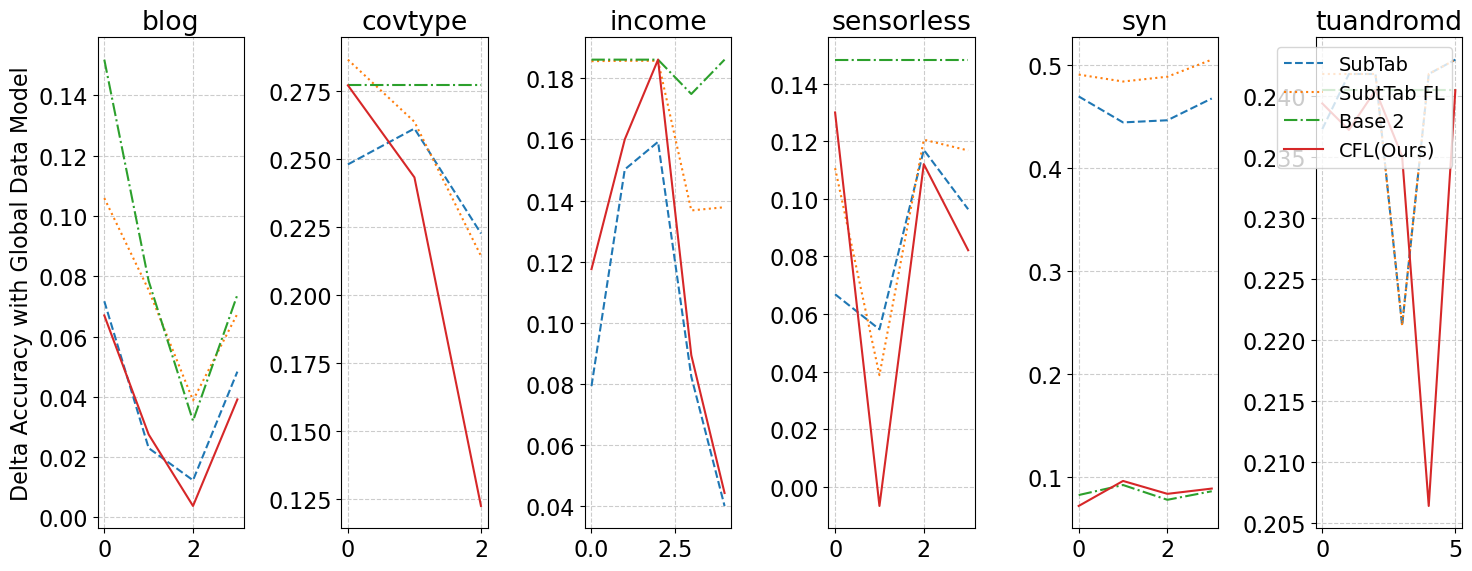

In [106]:

fig, axs = plt.subplots(1,len(dataset_list))
fig.set_figwidth(15)
fig.set_figheight(6)
for i,item in enumerate(dataset_list):
    # if item == 'income' : continue
    dPlot = dx[dx.dataset == item][['client','SubTab', 'SubTab FL','LR', 'CFL']].values
    if dPlot.shape[0] == 0 : continue
    axs[i].set_title(item)
    # axs[0,i].set_xlabel('Silo Number')
    
    axs[i].plot(dPlot[:,1],ls='dashed',label='SubTab')
    axs[i].plot(dPlot[:,2], ls='dotted',label='SubtTab FL')
    axs[i].plot(dPlot[:,3],ls='dashdot', label='Base 2')
    axs[i].plot(dPlot[:,4],ls = 'solid', label='CFL(Ours)')
    if(i==0) : axs[i].set_ylabel('Delta Accuracy with Global Data Model')
    if (i == len(dataset_list) -1) : axs[-1].legend(loc='upper right')
    # axs[i].xaxis.set_major_locator(MultipleLocator(int(sizeClient/4)))
    axs[i].grid(which='major', color='#CCCCCC', linestyle='--')
    
plt.tight_layout()    
fig.savefig('normalConf.png')

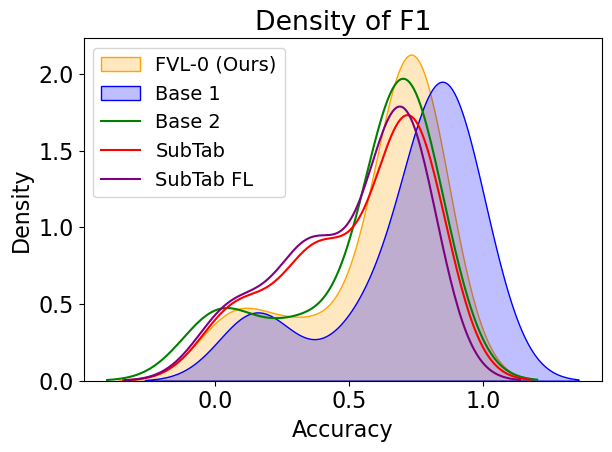

\begin{tabular}{lrrrrllllllllllll}
\toprule
\multicolumn{2}{r}{} & \multicolumn{3}{r}{Base} & \multicolumn{3}{r}{CFL (Ours)} & \multicolumn{3}{r}{LL} & \multicolumn{3}{r}{SubTab} & \multicolumn{3}{r}{SubTab-FL} \\
dataset & client & Precision & Recal & F1 & Precision & Recal & F1 & Precision & Recal & F1 & Precision & Recal & F1 & Precision & Recal & F1 \\
\midrule
blog & 1 & 0.79 & 0.80 & 0.79 & 0.73 & 0.73 & 0.73 & 0.74 & 0.63 & 0.64 & 0.72 & 0.73 & 0.72 & 0.71 & 0.68 & 0.69 \\
blog & 2 & 0.79 & 0.80 & 0.79 & 0.77 & 0.77 & 0.77 & 0.76 & 0.70 & 0.72 & 0.77 & 0.77 & 0.77 & 0.73 & 0.71 & 0.72 \\
blog & 3 & 0.79 & 0.80 & 0.79 & 0.80 & 0.79 & 0.79 & 0.78 & 0.75 & 0.76 & 0.79 & 0.78 & 0.78 & 0.77 & 0.75 & 0.76 \\
blog & 4 & 0.79 & 0.80 & 0.79 & 0.76 & 0.76 & 0.76 & 0.77 & 0.71 & 0.72 & 0.75 & 0.74 & 0.75 & 0.74 & 0.72 & 0.73 \\
covtype & 1 & 0.55 & 0.60 & 0.56 & 0.24 & 0.49 & 0.32 & 0.24 & 0.49 & 0.32 & 0.38 & 0.46 & 0.35 & 0.23 & 0.48 & 0.31 \\
covtype & 2 & 0.55 & 0.60 & 0.56 & 0.42 & 0.

In [111]:
dx = db[(db.client_drop==0)&(db.class_imbalance==0)]\
[['model','test_acc', 'client', 'dataset']]\
.pivot(index=['dataset','client'],
       values=['test_acc'],
       columns=['model'])\
.reset_index()
dx.columns = ['dataset','client','CFL','LL','SubTab','SubTab FL']
dx = dx.set_index('dataset').join(base.set_index('dataset'), how='left').reset_index()
# dx = dx[['dataset',' client','CFL','CFL-L','LL','SubTab','SubTab FL']]
dx[1] = np.vstack(dx['CFL'])[:,0]
dx[2] = np.vstack(dx['CFL'])[:,1]
dx[3] = np.vstack(dx['CFL'])[:,2]
dx[4] = np.vstack(dx['LL'])[:,0]
dx[5] = np.vstack(dx['LL'])[:,1]
dx[6] = np.vstack(dx['LL'])[:,2]
dx[7] = np.vstack(dx['SubTab'])[:,0]
dx[8] = np.vstack(dx['SubTab'])[:,1]
dx[9] = np.vstack(dx['SubTab'])[:,2]
dx[10] = np.vstack(dx['SubTab FL'])[:,0]
dx[11] = np.vstack(dx['SubTab FL'])[:,1]
dx[12] = np.vstack(dx['SubTab FL'])[:,2]
dx[13] = np.vstack(dx['test_acc'])[:,0]
dx[14] = np.vstack(dx['test_acc'])[:,1]
dx[15] = np.vstack(dx['test_acc'])[:,2]
dx = dx[['dataset', 'client', 1, 2, 3, 4, 5, 6, 7, 8, 9,10,11,12,13,14,15]]
dc = dx[['dataset',3,6,9,12,15]].rename(columns={3:'CFL (Ours)',6:'Base 2',9:'SubTab',12:'SubTab FL',15:'Base 1',}).set_index('dataset')
# dx[['dataset',3,6,12,15,18]].rename(columns={3:'CFL (Ours)',6:'Base 2',12:'SubTab',15:'SubTab FL',18:'Base 1',}).set_index('dataset').plot(kind='kde', title='Density of F1')

dc = dc[['CFL (Ours)', 'Base 1', 'Base 2', 'SubTab', 'SubTab FL']]

fig, ax = plt.subplots()
sns.kdeplot(data=dc.iloc[:,0], ax=ax, color='orange', fill=True, label='FVL-0 (Ours)')
sns.kdeplot(data=dc.iloc[:,1], ax=ax, color='blue', fill=True, label='Base 1')
sns.kdeplot(data=dc.iloc[:,2], ax=ax, color='green', fill=False, label='Base 2')
sns.kdeplot(data=dc.iloc[:,3], ax=ax, color='red', fill=False, label='SubTab')
sns.kdeplot(data=dc.iloc[:,4], ax=ax, color='purple', fill=False, label='SubTab FL')
# ax.legend(bbox_to_anchor=(1.02, 1.02), loc='upper left')
ax.legend(loc='upper left')

plt.xlabel('Accuracy')
plt.title('Density of F1')
plt.tight_layout()

plt.savefig('densityNormalConf.png')
plt.show()
dx.columns = cn
dx = dx[cnS]
dx.columns = pd.MultiIndex.from_tuples(dx.columns, names=['Model','Matrix'])

print(dx.to_latex(index=False, float_format="%.2f"))
# dc.head()

\begin{tabular}{lrllllllll}
\toprule
 & \multicolumn{5}{r}{Models} & \multicolumn{4}{r}{Delta} \\
Dataset & Base 1 & CFL (Ours) & Base 2 & SubTab & SubTab FL & CFL-B1 & B2-B1 & SubTab-B1 & SubTabFL-B1 \\
\midrule
blog & 0.791 & 0.761 & 0.712 & 0.757 & 0.724 & -0.030 & -0.080 & -0.035 & -0.068 \\
covtype & 0.561 & 0.387 & 0.324 & 0.357 & 0.346 & -0.174 & -0.237 & -0.204 & -0.214 \\
income & 0.811 & 0.709 & 0.644 & 0.726 & 0.662 & -0.102 & -0.166 & -0.085 & -0.149 \\
sensorless & 0.154 & 0.084 & 0.015 & 0.080 & 0.067 & -0.070 & -0.139 & -0.075 & -0.088 \\
syn & 0.859 & 0.776 & 0.776 & 0.403 & 0.368 & -0.084 & -0.083 & -0.456 & -0.491 \\
tuandromd & 0.939 & 0.709 & 0.701 & 0.704 & 0.703 & -0.230 & -0.237 & -0.235 & -0.235 \\
\bottomrule
\end{tabular}



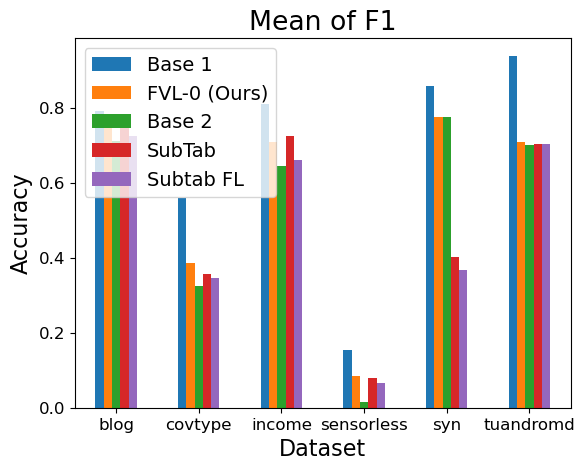

In [112]:
dxm = dx.groupby(('','dataset')).mean()
dxm = dxm.reset_index()
dxm.columns = cnR
dxm = dxm[['dataset','Base-F1','CFL-F1 (Ours)',
           # 'CFL-L-F1',
           'LL-F1','SubTab-F1','SubTab-FL-F1']]
dxm.columns = ['dataset','Base 1', 'FVL-0 (Ours)',
               # 'CFL Local',
               'Base 2', 'SubTab','Subtab FL']
dxm.set_index('dataset').plot(
    kind='bar', title='Mean of F1', rot=0, fontsize=12, xlabel='Dataset', ylabel='Accuracy'
    ).legend(loc='upper left')
plt.savefig('normalNewConf.png', bbox_inches='tight')
dxm['CFL-B1'] = dxm.iloc[:,2] -dxm.iloc[:,1]
dxm['B2-B1'] = dxm.iloc[:,3] -dxm.iloc[:,1]
dxm['SubTab-B1'] = dxm.iloc[:,4] -dxm.iloc[:,1]
dxm['SubTabFL-B1'] = dxm.iloc[:,5] -dxm.iloc[:,1]
dxm.columns = [('','Dataset'),
               ('Models','Base 1'),('Models','CFL (Ours)'),('Models','Base 2'),('Models','SubTab'),('Models','SubTab FL'),
               ('Delta', 'CFL-B1'),('Delta', 'B2-B1'),('Delta', 'SubTab-B1'),('Delta', 'SubTabFL-B1'),
              ]
dxm.columns = pd.MultiIndex.from_tuples(dxm.columns, names=['Model','Matrix'])
print(dxm.to_latex(index=False, float_format="%.3f"))


## Precision

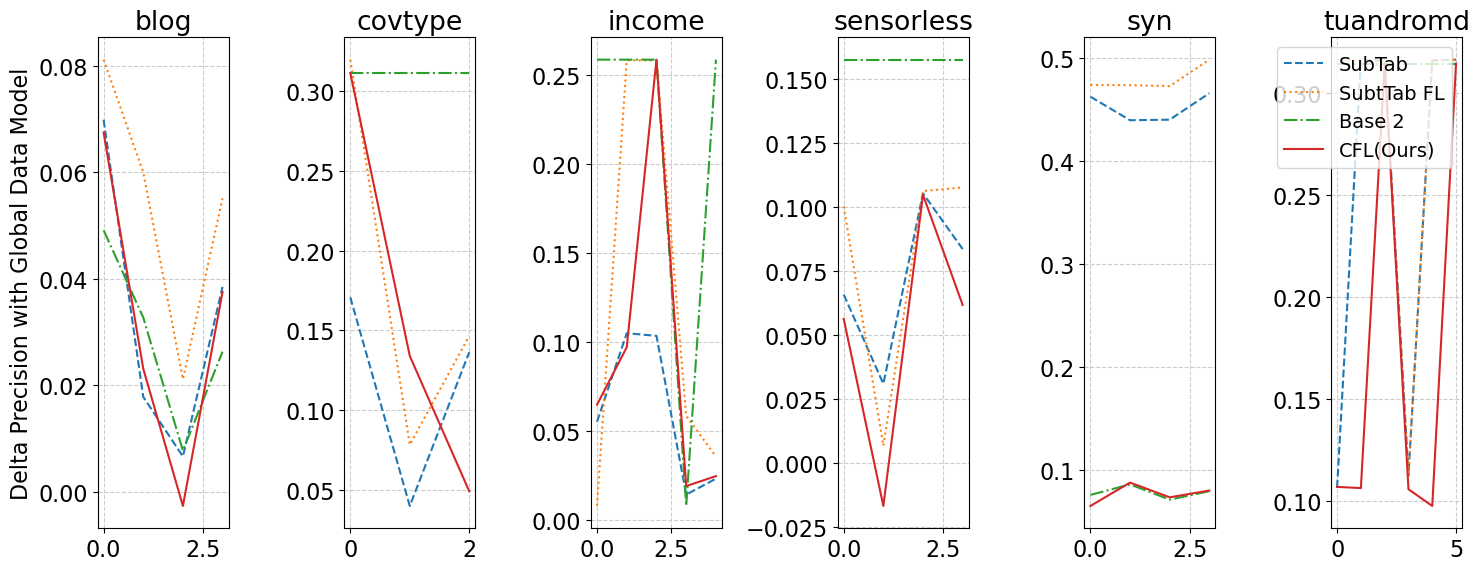

In [109]:
dgx = dx.copy()
dgx.columns = ['dataset','client',1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
dgx = dgx[['dataset','client',1,4,7,10,13]]
dgx.columns = ['dataset','client','Base','CFL','LR','SubTab','SubTabFL']
dgx['dSubTab'] = dgx.Base -  dgx.SubTab
dgx['dSubTabFL'] = dgx.Base - dgx.SubTabFL
dgx['dLL'] = dgx.Base - dgx.LR
dgx['dCFL'] = dgx.Base -  dgx.CFL
# dgx['dCFLLocal'] = dgx.Base -  dgx.CFLLocal
dgx = dgx[['client', 'dataset', 'dCFL','dLL','dSubTab', 'dSubTabFL']]
dgx.columns = ['client', 'dataset', 'CFL', 'LR','SubTab', 'SubTab FL']
fig, axs = plt.subplots(1,len(dataset_list))
fig.set_figwidth(15)
fig.set_figheight(6)
for i,item in enumerate(dataset_list):
    # if item == 'income' : continue
    dPlot = dgx[dgx.dataset == item][['client','SubTab', 'SubTab FL','LR', 'CFL']].values
    if dPlot.shape[0] == 0 : continue
    axs[i].set_title(item)
    # axs[0,i].set_xlabel('Silo Number')
    
    axs[i].plot(dPlot[:,1],ls='dashed',label='SubTab')
    axs[i].plot(dPlot[:,2], ls='dotted',label='SubtTab FL')
    axs[i].plot(dPlot[:,3],ls='dashdot', label='Base 2')
    axs[i].plot(dPlot[:,4],ls = 'solid', label='CFL(Ours)')
    if(i==0) : axs[i].set_ylabel('Delta Precision with Global Data Model')
    if (i == len(dataset_list) -1) : axs[-1].legend(loc='upper right')
    # axs[i].xaxis.set_major_locator(MultipleLocator(int(sizeClient/4)))
    axs[i].grid(which='major', color='#CCCCCC', linestyle='--')
    
plt.tight_layout()    
fig.savefig('precissionConf.png')

## Recall

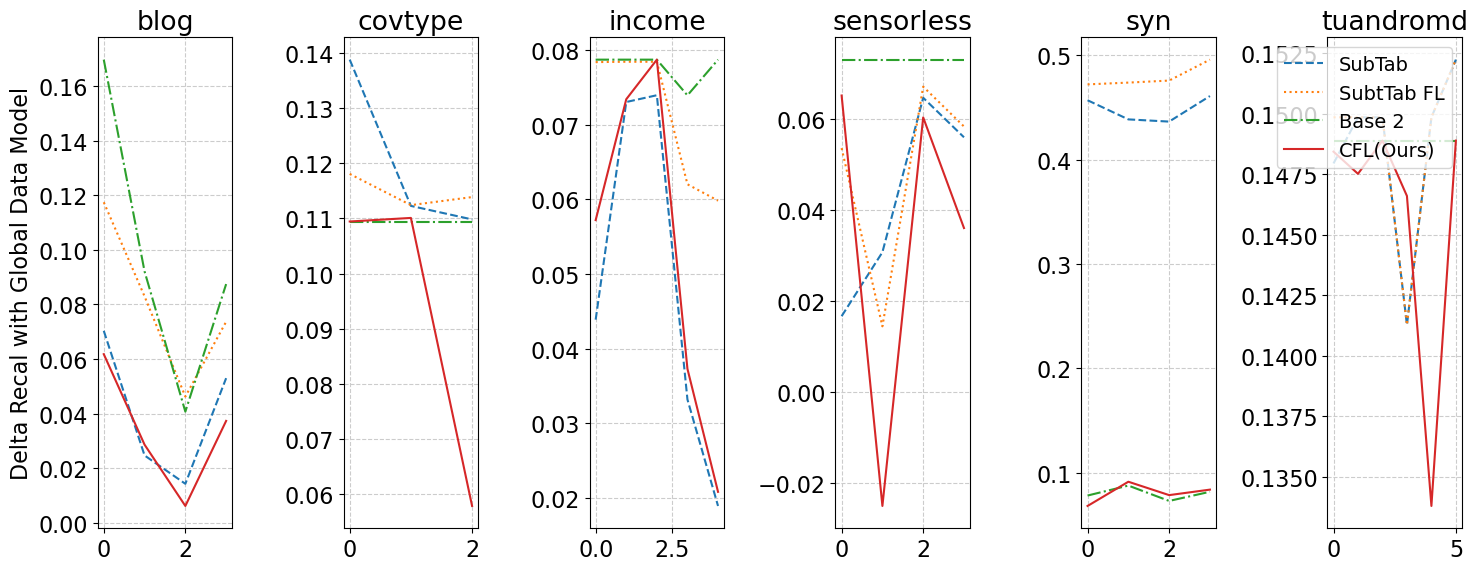

In [110]:
dgx = dx.copy()
dgx.columns = ['dataset','client',1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
dgx = dgx[['dataset','client',2,5,8,11,14]]
dgx.columns = ['dataset','client','Base','CFL','LR','SubTab','SubTabFL']
dgx['dSubTab'] = dgx.Base -  dgx.SubTab
dgx['dSubTabFL'] = dgx.Base - dgx.SubTabFL
dgx['dLL'] = dgx.Base - dgx.LR
dgx['dCFL'] = dgx.Base -  dgx.CFL
# dgx['dCFLLocal'] = dgx.Base -  dgx.CFLLocal
dgx = dgx[['client', 'dataset', 'dCFL','dLL','dSubTab', 'dSubTabFL']]
dgx.columns = ['client', 'dataset', 'CFL', 'LR','SubTab', 'SubTab FL']
fig, axs = plt.subplots(1,len(dataset_list))
fig.set_figwidth(15)
fig.set_figheight(6)
for i,item in enumerate(dataset_list):
    # if item == 'income' : continue
    dPlot = dgx[dgx.dataset == item][['client','SubTab', 'SubTab FL','LR', 'CFL']].values
    if dPlot.shape[0] == 0 : continue
    axs[i].set_title(item)
    # axs[0,i].set_xlabel('Silo Number')
    
    axs[i].plot(dPlot[:,1],ls='dashed',label='SubTab')
    axs[i].plot(dPlot[:,2], ls='dotted',label='SubtTab FL')
    axs[i].plot(dPlot[:,3],ls='dashdot', label='Base 2')
    axs[i].plot(dPlot[:,4],ls = 'solid', label='CFL(Ours)')
    if(i==0) : axs[i].set_ylabel('Delta Recal with Global Data Model')
    if (i == len(dataset_list) -1) : axs[-1].legend(loc='upper right')
    # axs[i].xaxis.set_major_locator(MultipleLocator(int(sizeClient/4)))
    axs[i].grid(which='major', color='#CCCCCC', linestyle='--')
    
plt.tight_layout()    
fig.savefig('recalConf.png')